<a href="https://colab.research.google.com/github/ananyagupta-31/ananyagupta-31/blob/main/Traffic_Flow_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Traffic Flow Prediction

1. Install Required Libraries

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

2. Complete Code

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rgupta12/metro-interstate-traffic-volume")

print("Path to dataset files:", path)

100%|██████████| 1.12M/1.12M [00:00<00:00, 88.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rgupta12/metro-interstate-traffic-volume/versions/1


In [6]:
df = pd.read_csv(f'{path}/Metro_Interstate_Traffic_Volume.csv')
df['date_time'] = pd.to_datetime(df['date_time'])

In [7]:
# Extract features
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month

In [8]:
# Create target variable (Traffic Level)
def categorize_traffic(volume):
    if volume < 2000:
        return 0   # Low
    elif volume < 4000:
        return 1   # Medium
    else:
        return 2   # High

df['traffic_level'] = df['traffic_volume'].apply(categorize_traffic)

In [9]:
# Encode weather
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

In [10]:
# Features and target
X = df.drop(['traffic_volume', 'traffic_level', 'date_time'], axis=1)
y = df['traffic_level']

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Model
model = RandomForestClassifier(n_estimators=100)

# Identify non-numeric (object type) columns, likely the 'holiday' column
non_numeric_cols = X_train.select_dtypes(include=['object']).columns

if not non_numeric_cols.empty:
    # Apply one-hot encoding to identified categorical columns
    X_train_processed = pd.get_dummies(X_train, columns=non_numeric_cols, drop_first=True)
    X_test_processed = pd.get_dummies(X_test, columns=non_numeric_cols, drop_first=True)

    # Align columns to ensure both train and test sets have the same features
    train_cols = set(X_train_processed.columns)
    test_cols = set(X_test_processed.columns)

    # Add missing columns to X_test_processed and fill with 0
    missing_in_test = train_cols - test_cols
    for col in missing_in_test:
        X_test_processed[col] = 0

    # Add missing columns to X_train_processed and fill with 0
    missing_in_train = test_cols - train_cols
    for col in missing_in_train:
        X_train_processed[col] = 0

    # Ensure the order of columns is the same for both sets
    X_test_processed = X_test_processed[X_train_processed.columns]

    # Use the processed data for training
    model.fit(X_train_processed, y_train)
else:
    # If no non-numeric columns found, proceed with original X_train
    model.fit(X_train, y_train)

In [15]:
# Prediction
y_pred = model.predict(X_test_processed)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.8657815579296754

Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88      3032
           1       0.81      0.71      0.75      2368
           2       0.87      0.97      0.91      4241

    accuracy                           0.87      9641
   macro avg       0.86      0.84      0.85      9641
weighted avg       0.86      0.87      0.86      9641



3. Visualization Code

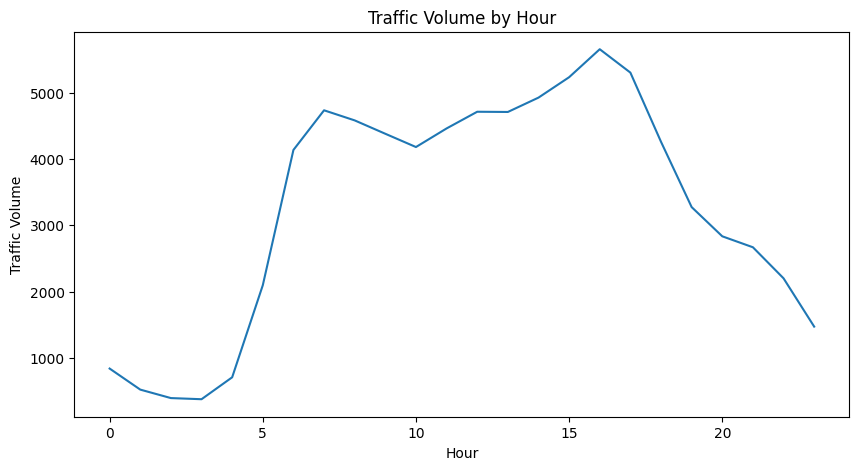

In [17]:
plt.figure(figsize=(10,5))
df.groupby('hour')['traffic_volume'].mean().plot()
plt.title("Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic Volume")
plt.show()

4. Simple Prediction Function

In [19]:
def predict_traffic(hour, temp):
    # Create a sample DataFrame with the same column structure as the processed training data
    # This ensures that the feature names match what the model was trained on.
    sample = X_train_processed.iloc[0:1].copy()

    # Update the hour and temp values in the sample
    sample['hour'] = hour
    sample['temp'] = temp

    pred = model.predict(sample)

    if pred[0] == 0:
        return "Low Traffic 🚗"
    elif pred[0] == 1:
        return "Medium Traffic 🚗🚗"
    else:
        return "High Traffic 🚗🚗🚗"

print(predict_traffic(8, 280))

High Traffic 🚗🚗🚗
